In [93]:
import torch
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC
from torch.utils.data import Dataset
from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss
import matplotlib.pyplot as plt
import seaborn as sns
# from initial_param_dataloader import *

In [2]:
data_dict = {}
file_dict = {'vr': "vr002.hdf", 
             'br': "br002.hdf", 
             'vt': "vt002.hdf", 
             'vp': "vp002.hdf", 
             'bt': "bt002.hdf", 
             'bp': "bp002.hdf", 
             'jt': "jt002.hdf", 
             'jp': "jp002.hdf", 
             'jr': "jr002.hdf", 
             'rho': "rho002.hdf", 
             'p': "p002.hdf"
}
FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]


In [22]:
# b = [read_hdf(path_join(sim_path, f'kpo_mas_mas_std_0101/{file}'), ['Data-Set-2']) for file in FILE_NAMES]

In [96]:
DATA_DIR = "/data/solar_wind_pred_vignesh/hdf/high"

sim_path = path_join(DATA_DIR, 'cr2240/hmi_mast_mas_std_0101')

In [24]:
# def get_coords(sim_path):
#     v_path = path_join(sim_path, FILE_NAMES[0])
    
#     thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
#     return thetas, phis

In [25]:
get_coords(sim_path)[0].shape, get_coords(sim_path)[1].shape

((111,), (128,))

In [97]:
import torch
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC
from torch.utils.data import Dataset
from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]

DEFAULT_INSTRUMENTS = [
    "kpo_mas_mas_std_0101",
    "mdi_mas_mas_std_0101",
    "hmi_mast_mas_std_0101",
    "hmi_mast_mas_std_0201",
    "hmi_masp_mas_std_0201",
    "mdi_mas_mas_std_0201",
]


def read_hdf(hdf_path, dataset_names):
    f = SD(hdf_path, SDC.READ)
    datasets = []
    for dataset_name in dataset_names:
        datasets.append(f.select(dataset_name).get())
    return datasets


def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
    return thetas, phis


def get_sim(sim_path, scale_up):
    # (v_path,) = [path_join(sim_path, file_name) for file_name in FILE_NAMES]
    v = [read_hdf(path_join(sim_path, file_name), ['Data-Set-2']) for file_name in FILE_NAMES]
    print(v[0].shape)
    v_0 = np.array([t[0][:,:110,0] for t in v])
    v_0 = v_0.transpose(0,2,1)

    if scale_up != 1:
        v_0 = enlarge_cube(v_0, scale_up)
    return v_0


def get_sims(sim_paths, scale_up, pos_emb = None):
    sims = []
    thetas, phis = get_coords(sim_paths[0])  # (140,), (111,), (128,)
    
    # Broadcast coordinate grids
    T, P = np.meshgrid(thetas, phis, indexing="ij")  # shapes (140, 111, 128)

    # Normalize angles for embeddings
    T_norm = T / np.pi       # θ ∈ [0, π] → [0,1]
    P_cos = np.cos(P)        # periodic encoding
    P_sin = np.sin(P)

    for sim_path in tqdm(sim_paths, desc="Loading simulations"):
        sim = get_sim(sim_path, scale_up)  # (140, 111, 128)

        if pos_emb == "pt":
            # Embed only angular coords
            # stack channels: [sim, θ, cos φ, sin φ]
            sim_emb = np.stack([sim, T_norm, P_cos, P_sin], axis=0)  # (C=4, 140, 111, 128)

        elif pos_emb == "ptr":
            # Embed radius too
            # R_norm = (R - R.min()) / (R.max() - R.min())
            # sim_emb = np.stack([sim, R_norm, T_norm, P_cos, P_sin], axis=0)  # (C=5, 140, 111, 128)
            pass

        else:
            sim_emb = sim # (11, 111, 128)
        sims.append(sim_emb)

    sims = np.stack(sims, axis=0)  # (N, 11, 111, 128)
    return sims, (thetas, phis)



def enlarge_cube(cube, scale):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale, scale), order=1)


# def min_max_normalize(array, min_=None, max_=None):
#     if min_ is None or max_ is None:
#         min_ = np.min(array[:, 0, :, :, :])
#         max_ = np.max(array[:, 0, :, :, :])
#     array[:, 0, :, :, :] = (array[:, 0, :, :, :] - min_) / (max_ - min_ + 1e-9)
#     return array, min_, max_

def min_max_normalize(array, min_=None, max_=None, transform='log', transform_fn = None):
    '''
    Apply an optional transformation to the data before min-max normalization.
    :param array: Input array of shape (N, 11, H, W)
    '''
    if transform == 'log':
        array = np.log(array)
    elif transform == 'sqrt':
        array= np.sqrt(array)
    elif transform_fn != None:
        array = transform_fn(array)
        
    min_ = np.min(array, axis=(0,2,3)) 
    max_ = np.max(array, axis=(0,2,3))
    array = (array - min_[:, None, None]) / (max_[:, None, None] - min_[:, None, None] + 1e-9)
    
    return array, torch.from_numpy(min_), torch.from_numpy(max_)

def compute_climatology(data: np.ndarray, scale_up) -> np.ndarray:
    """
    Compute per-voxel climatology (mean field) from a dataset.

    Args:
        data (np.ndarray): Array of shape (n, 139, 111, 128)

    Returns:
        np.ndarray: Climatology array of shape (139, 111, 128)
    """
    assert data.ndim == 4 and data.shape[1:] == (
        139,
        111 * scale_up,
        128 * scale_up,
    ), "Unexpected input shape."
    climatology = np.mean(data, axis=0)
    climatology = torch.tensor(climatology, dtype=torch.float32)
    return climatology


def get_cr_dirs(data_path):
    """Return list of CR directories (crXXXX) inside data_path."""
    cr_dirs = sorted(
        [
            d
            for d in os.listdir(data_path)
            if d.startswith("cr") and os.path.isdir(os.path.join(data_path, d))
        ]
    )
    return cr_dirs


def collect_sim_paths(data_path, cr_list, instruments=None):
    """Collect simulation paths given a list of CR directories."""
    if instruments is None:
        instruments = DEFAULT_INSTRUMENTS

    sim_paths = []
    for cr in cr_list:
        cr_path = os.path.join(data_path, cr)
        for instrument in instruments:
            instrument_path = os.path.join(cr_path, instrument)
            if os.path.exists(instrument_path):
                sim_paths.append(instrument_path)
    return sim_paths


class InitialParamDataset(Dataset):
    def __init__(
        self,
        data_path,
        cr_list,
        v_min=None,
        v_max=None,
        instruments=None,
        scale_up=1,
        pos_embedding = None,
        transform=None,
        transform_fn = None
    ):
        super().__init__()
        self.sim_paths = collect_sim_paths(data_path, cr_list, instruments)
        sims, _ = get_sims(self.sim_paths, scale_up, pos_embedding)
        # sims, self.v_min, self.v_max = min_max_normalize(sims, v_min, v_max, transform=transform, transform_fn=transform_fn)
        self.sims = sims
        # self.climatology = compute_climatology(sims[:, 0, 1:, :, :], scale_up)

    def __getitem__(self, index):
        cube = self.sims[index]
        # print(self.sims.shape)

        # print(cube.shape)
        return {
            "x": torch.tensor(cube[:2], dtype=torch.float32),
            "y": torch.tensor(cube[2:], dtype=torch.float32),
        }

    def __len__(self):
        return len(self.sims)

    def get_min_max(self):
        return {"v_min": [float(v) for v in self.v_min], "v_max": [float(v) for v in self.v_max]}

    def get_grid_points(self):
        return get_coords(self.sim_paths[0])


In [98]:
cr_dirs = get_cr_dirs(DATA_DIR)

In [99]:
train_data = InitialParamDataset(
    DATA_DIR,
    cr_dirs[:3])
    

Loading simulations:   0%|                                                                                                                                                                     | 0/9 [00:14<?, ?it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (11,) + inhomogeneous part.

In [7]:
b = train_data.__getitem__(0)
b['x'].shape, b['y'].shape

(torch.Size([2, 110, 128]), torch.Size([9, 110, 128]))

(torch.Size([2, 110, 128]), torch.Size([9, 110, 128]))

In [12]:
train_data.get_min_max()

{'v_min': [0.5342956781387329,
  -0.0006156648742035031,
  -0.018703000620007515,
  -0.0079679936170578,
  -1.2436613360478077e-05,
  -0.00014901945542078465,
  -0.00012280249211471528,
  -0.0003814245865214616,
  -6.34558527963236e-05,
  1.5741799188617733e-06,
  1.6932939672642533e-07],
 'v_max': [1.3503096103668213,
  0.0008693619747646153,
  0.014642676338553429,
  0.010765140876173973,
  1.7746706362231635e-05,
  9.951100219041109e-05,
  0.00015254513709805906,
  0.0003753132186830044,
  5.972045983071439e-05,
  1.0178308002650738e-05,
  3.191809412328439e-07]}

In [50]:
[i[0].shape for i in b]

[(128, 111, 140),
 (128, 110, 141),
 (128, 110, 141),
 (128, 111, 141),
 (128, 111, 140),
 (128, 110, 140),
 (128, 110, 141),
 (128, 111, 141),
 (128, 111, 140),
 (128, 111, 141),
 (128, 111, 141)]

In [51]:
radii, thetas, phis = read_hdf(path_join(sim_path, f'kpo_mas_mas_std_0101/br002.hdf'), ["fakeDim2", "fakeDim1", "fakeDim0"])

In [52]:
radii

array([ 29.257338,  30.742662,  32.227985,  33.71331 ,  35.19863 ,
        36.683956,  38.16928 ,  39.654606,  41.139927,  42.62525 ,
        44.110577,  45.595898,  47.081223,  48.566547,  50.051872,
        51.537193,  53.02252 ,  54.507843,  55.993164,  57.47849 ,
        58.963814,  60.449135,  61.93446 ,  63.419785,  64.905106,
        66.390434,  67.875755,  69.36108 ,  70.846405,  72.331726,
        73.81705 ,  75.302376,  76.7877  ,  78.27302 ,  79.75835 ,
        81.24367 ,  82.729   ,  84.21432 ,  85.69964 ,  87.18497 ,
        88.67029 ,  90.15561 ,  91.64094 ,  93.12626 ,  94.61158 ,
        96.09691 ,  97.58223 ,  99.06755 , 100.55288 , 102.0382  ,
       103.52352 , 105.00885 , 106.49417 , 107.9795  , 109.46482 ,
       110.95014 , 112.43547 , 113.92079 , 115.40611 , 116.89144 ,
       118.37676 , 119.86208 , 121.34741 , 122.83273 , 124.318054,
       125.80338 , 127.288704, 128.77403 , 130.25935 , 131.74467 ,
       133.23    , 134.71532 , 136.20065 , 137.68597 , 139.171

In [53]:
r

array([ 30.      ,  31.485323,  32.970646,  34.45597 ,  35.941296,
        37.42662 ,  38.91194 ,  40.397266,  41.88259 ,  43.367912,
        44.853237,  46.338562,  47.823883,  49.309208,  50.794533,
        52.279858,  53.76518 ,  55.250504,  56.73583 ,  58.22115 ,
        59.706474,  61.1918  ,  62.677124,  64.162445,  65.647766,
        67.133095,  68.618416,  70.103745,  71.589066,  73.07439 ,
        74.559715,  76.04504 ,  77.53036 ,  79.015686,  80.50101 ,
        81.98633 ,  83.47166 ,  84.95698 ,  86.4423  ,  87.92763 ,
        89.41295 ,  90.89827 ,  92.3836  ,  93.86892 ,  95.35425 ,
        96.83957 ,  98.32489 ,  99.81022 , 101.29554 , 102.78086 ,
       104.26619 , 105.75151 , 107.23683 , 108.72216 , 110.20748 ,
       111.6928  , 113.17813 , 114.66345 , 116.14877 , 117.6341  ,
       119.11942 , 120.60475 , 122.09007 , 123.57539 , 125.06072 ,
       126.54604 , 128.03137 , 129.5167  , 131.00201 , 132.48734 ,
       133.97266 , 135.458   , 136.94331 , 138.42863 , 139.913

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
pred = np.random.randn(9,110,128)
y_true = np.random.randn(9,110,128)

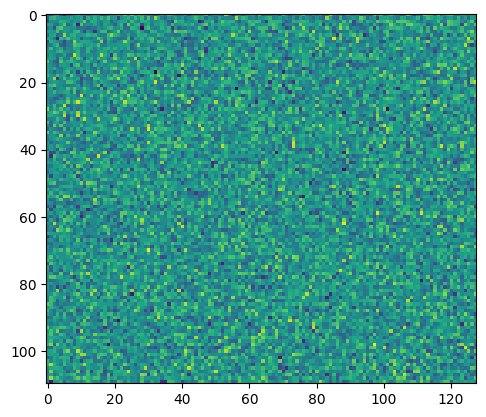

In [6]:
plt.imshow(pred[0])
plt.show()

In [11]:
LABELS = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]

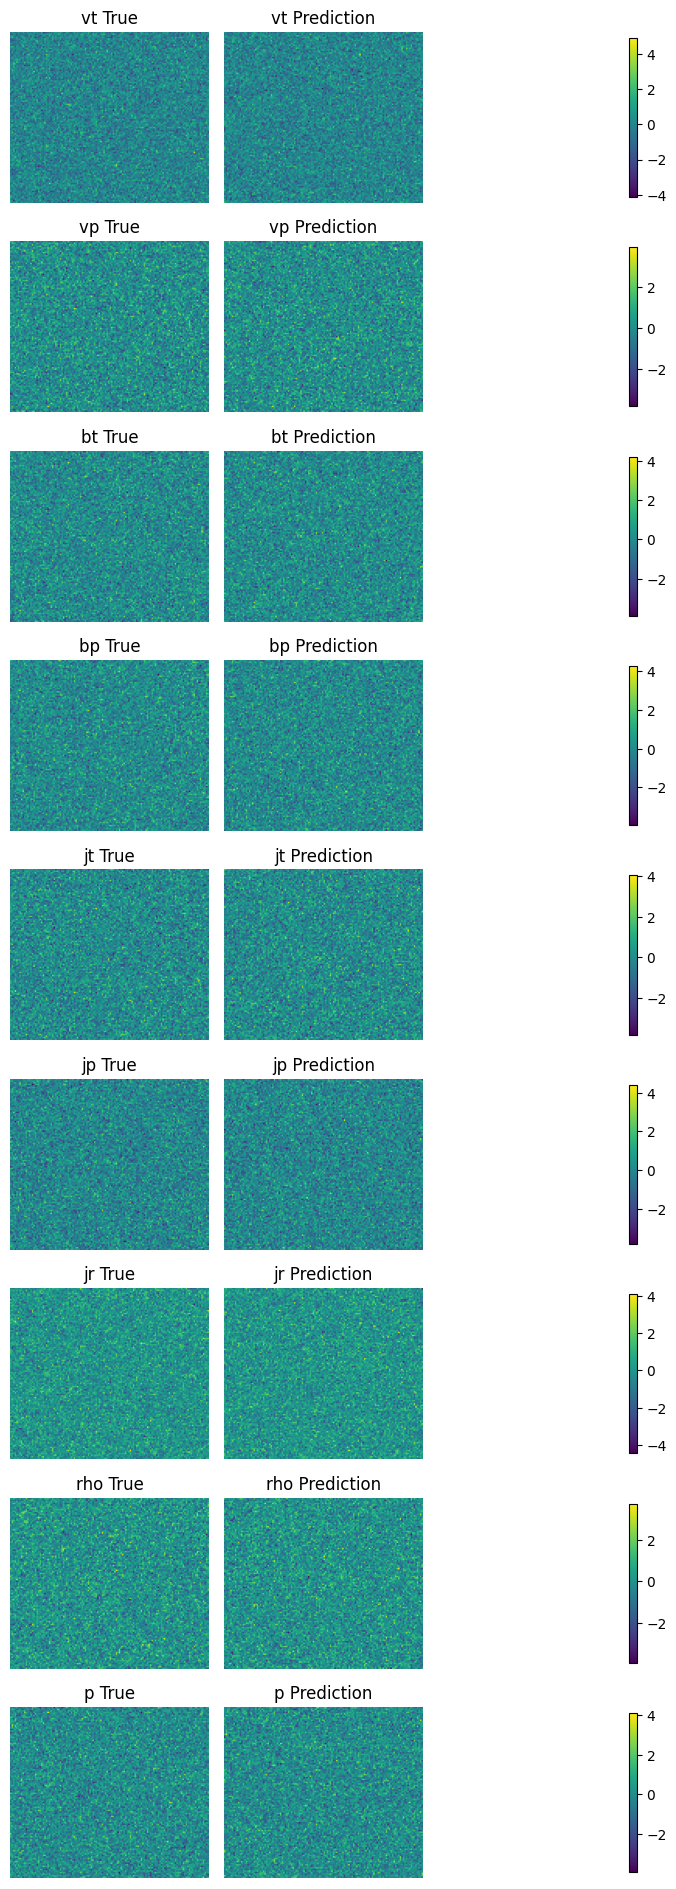

In [19]:
fig, ax = plt.subplots(9,3, figsize=(7,19))
for i in range(9):
    vmin = np.min([y_true[i].min(), pred[i].min()])
    vmax = np.max([y_true[i].max(), pred[i].max()])

    im0 = ax[i, 0].imshow(y_true[i], cmap='viridis', vmin=vmin, vmax=vmax)
    ax[i, 0].axis('off')
    ax[i, 0].set_title(f'{LABELS[i]} True')

    im1 = ax[i, 1].imshow(pred[i], cmap='viridis', vmin=vmin, vmax=vmax)
    ax[i, 1].axis('off')
    ax[i, 1].set_title(f'{LABELS[i]} Prediction')
    ax[i, 2].axis('off')
    # colorbar for each image, same scale (vmin/vmax) within the row
    # fig.colorbar(im0, ax=ax[i, 0], fraction=0.046, pad=0.02)
    fig.colorbar(im1, ax=ax[i, 2], fraction=0.04, pad=0.03)
plt.tight_layout()

plt.show()

In [32]:
b['x'].shape, b['y'].shape

(torch.Size([2, 110, 128]), torch.Size([9, 110, 128]))

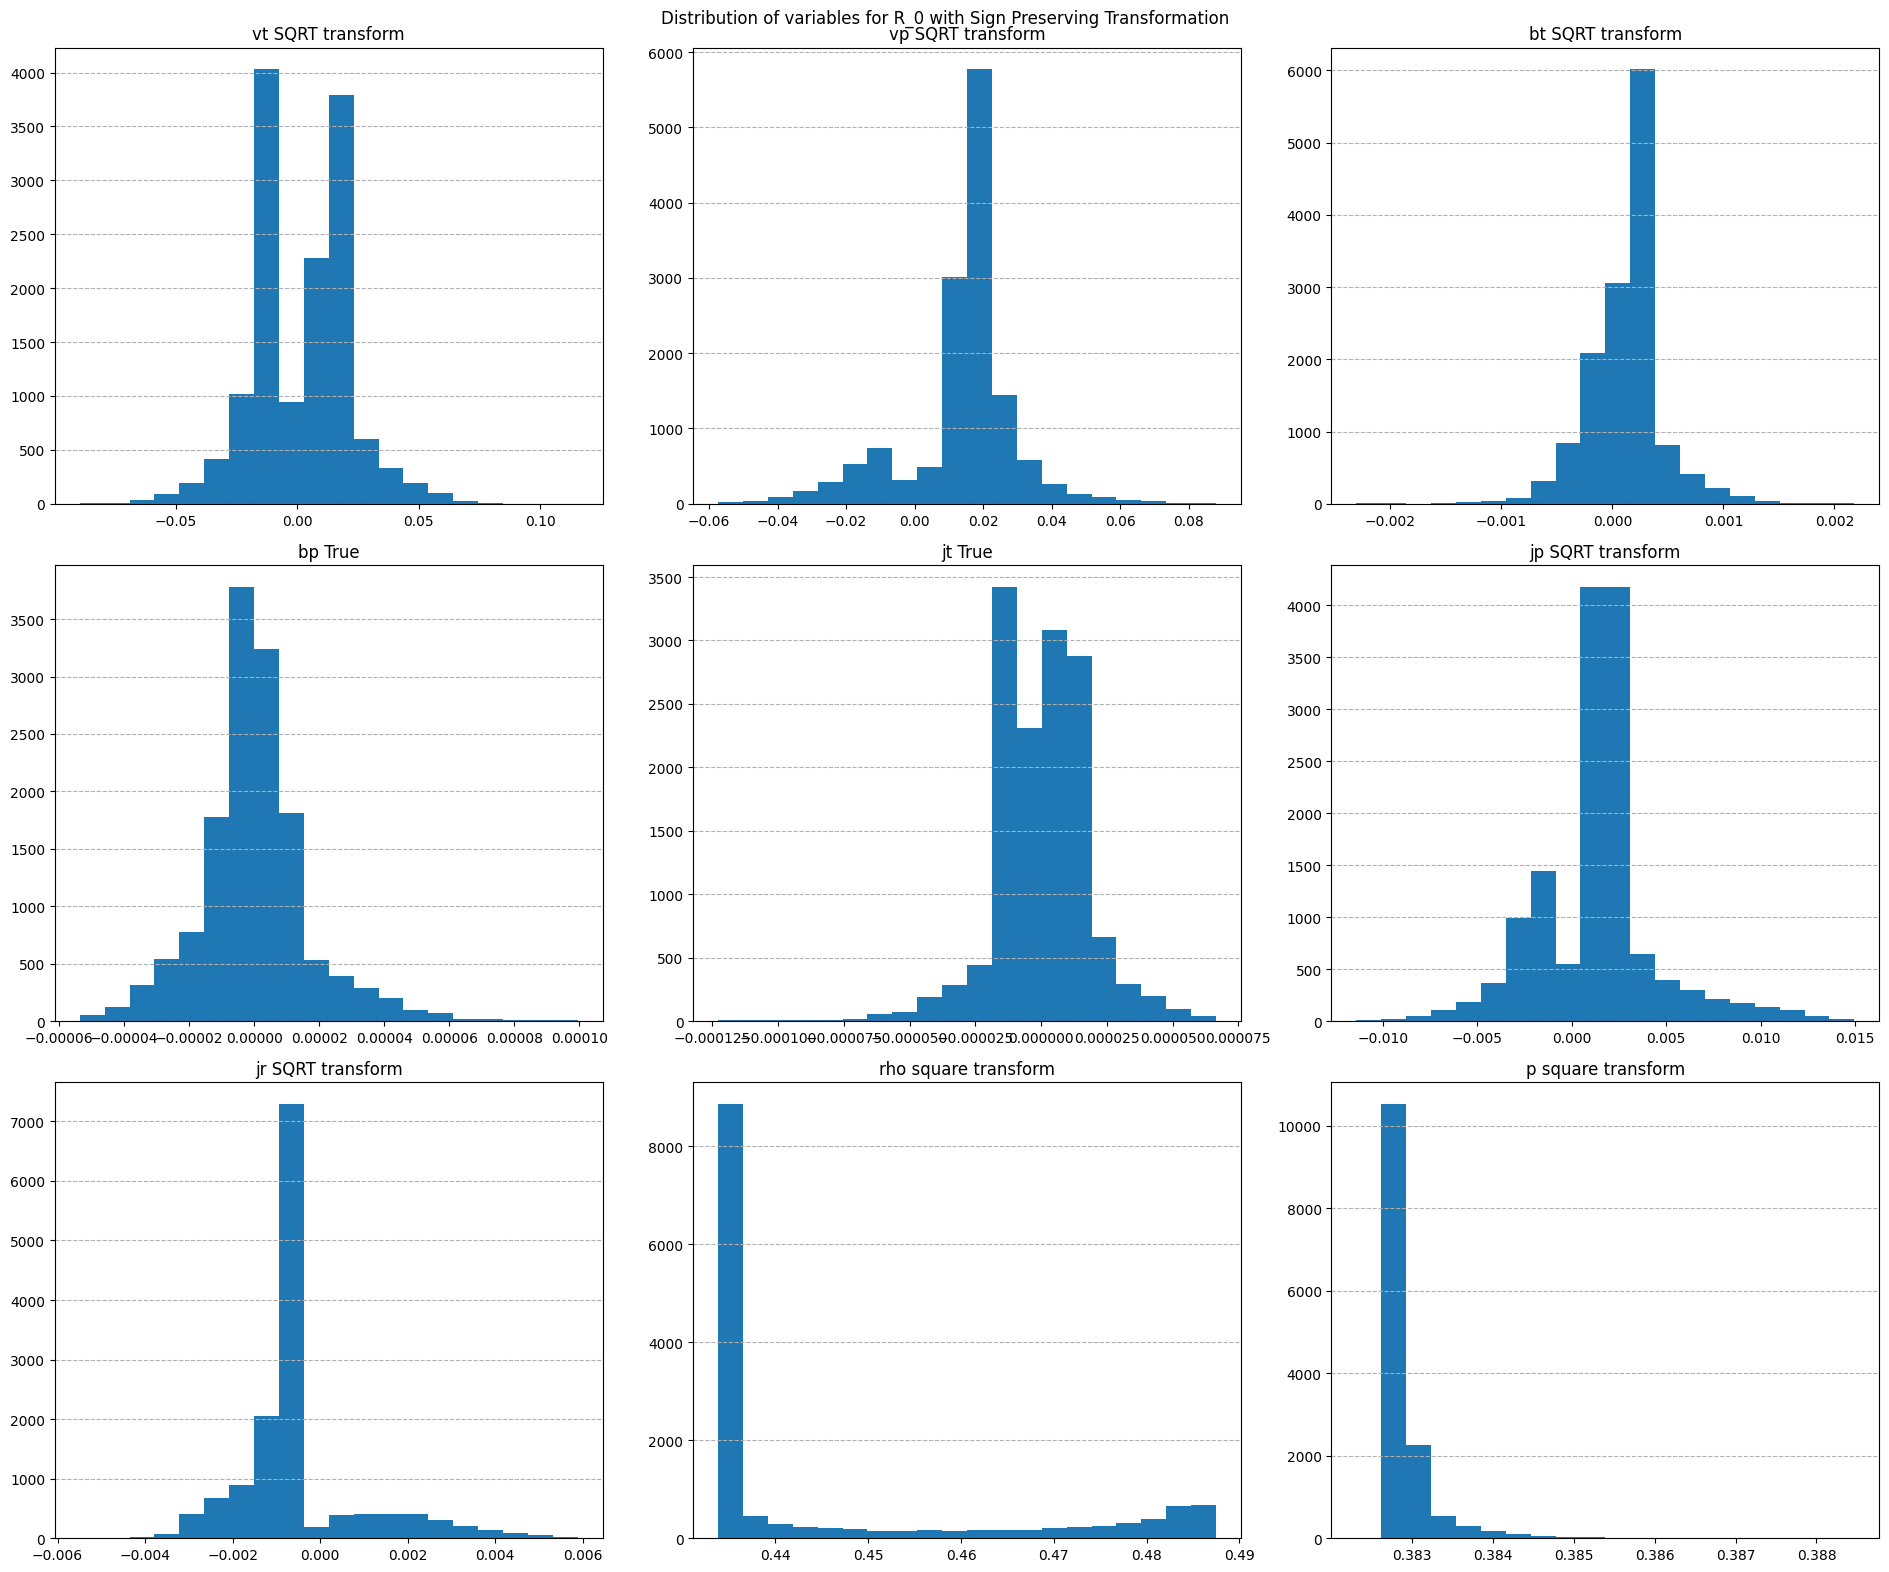

In [51]:
# plt.hist(b['y'][0].reshape(-1))
# plt.show()

save_filepath = 'histogram_distribution'
save_filename = 'Signed_MIXED_normalization'
fig, ax = plt.subplots(3,3, figsize=(19,16))
for i in range(9):
    data = b['y'][i]
    postfix = 'True'
    if LABELS[i] in {'vt', 'vp','bt', 'jp', 'jr'}:
        data = np.sign(data)* (np.abs(data)**0.5)
        # data=np.sign(data)* np.log(np.abs(data))
        postfix = 'SQRT transform'
        data = data.reshape(-1)
    elif LABELS[i] in {'rho', 'p'}:
        data = np.sign(data)* (np.abs(data)**(1/16))
        postfix = 'square transform'
        data = data.reshape(-1)
    else:
        data = data.reshape(-1)
    ax[i//3, i%3].hist(data, bins=20)
    ax[i//3, i%3].set_title(f'{LABELS[i]} {postfix}')
    # ax[i//3, i%3].set_yscale('log')
    ax[i//3, i%3].grid(axis='y', linestyle='--', which='major')
plt.suptitle(f'Distribution of variables for R_0 with Sign Preserving Transformation')
plt.tight_layout()
# plt.savefig(f'{save_filepath}/{save_filename}.png', dpi=200)
# plt.savefig(f'{save_filepath}/{save_filename}.pdf', dpi=200)
plt.show()

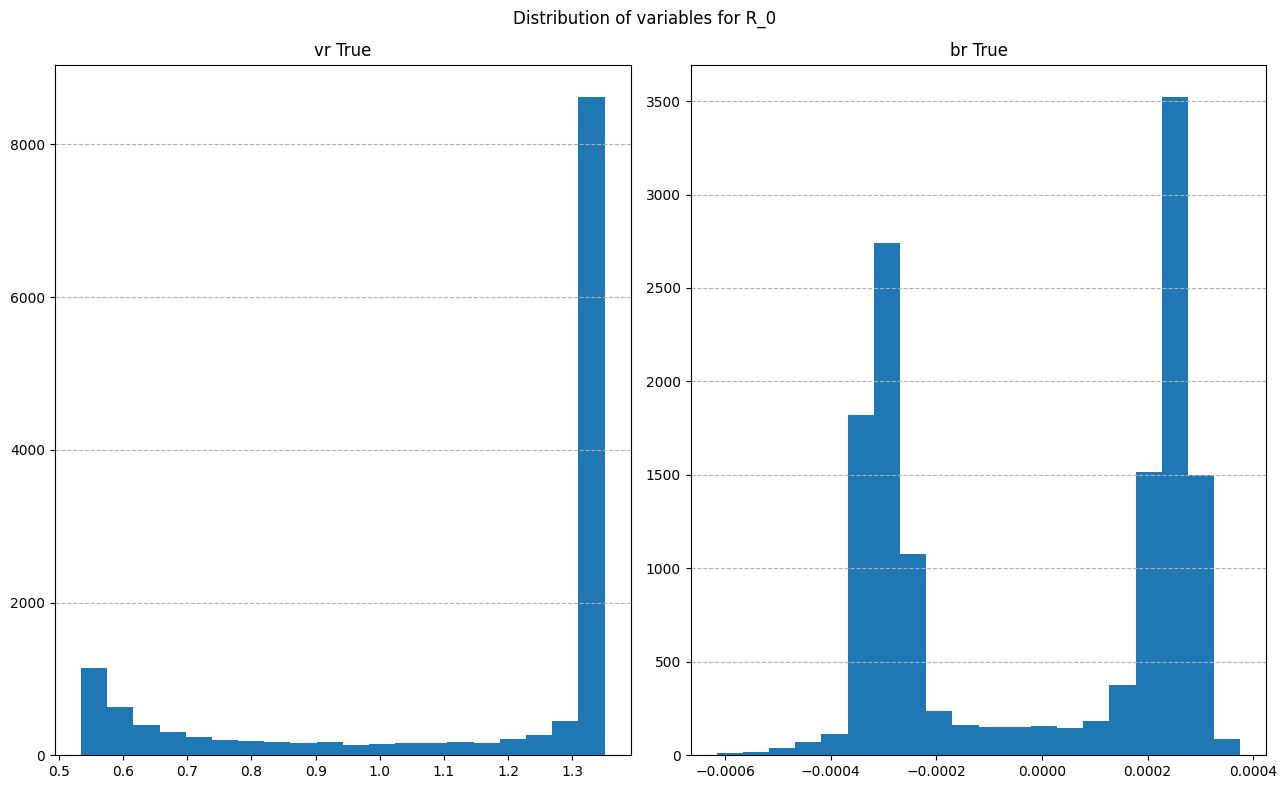

In [47]:
INPUT_LABELS = ['vr', 'br']
fig, ax = plt.subplots(1,2, figsize=(13,8))
for i in range(2):
    data = b['x'][i]
    postfix = 'True'
    # if LABELS[i] in {'vt', 'vp','bt', 'jp', 'jr'}:
    #     data = np.sign(data)* (np.abs(data)**0.5)
    #     # data=np.sign(data)* np.log(np.abs(data))
    #     postfix = 'SQRT transform'
    #     data = data.reshape(-1)
    # elif LABELS[i] in {'rho', 'p'}:
    #     data = np.sign(data)* (np.abs(data)**0.25)
    #     postfix = 'square transform'
    #     data = data.reshape(-1)
    # else:
    data = data.reshape(-1)
    ax[i%2].hist(data, bins=20)
    ax[i%2].set_title(f'{INPUT_LABELS[i]} {postfix}')
    # ax[i//3, i%3].set_yscale('log')
    ax[i%2].grid(axis='y', linestyle='--', which='major')
plt.suptitle(f'Distribution of variables for R_0')
plt.tight_layout()
# plt.savefig(f'{save_filepath}/{save_filename}.png', dpi=200)
plt.savefig(f'{save_filepath}/input_variables.pdf', dpi=200)
plt.show()

In [74]:
def sqrt_transform(X):
    return np.sign(X)*np.sqrt(np.abs(X))
def log_transform(X):
    return np.sign(X)*np.log(np.abs(X))
def power_transform(X, power=2):
    return np.sign(X)*np.power(np.abs(X), power)
def exp_transform(X):
    return np.exp(X)

In [91]:
feat = LABELS.index('p')
feat

8

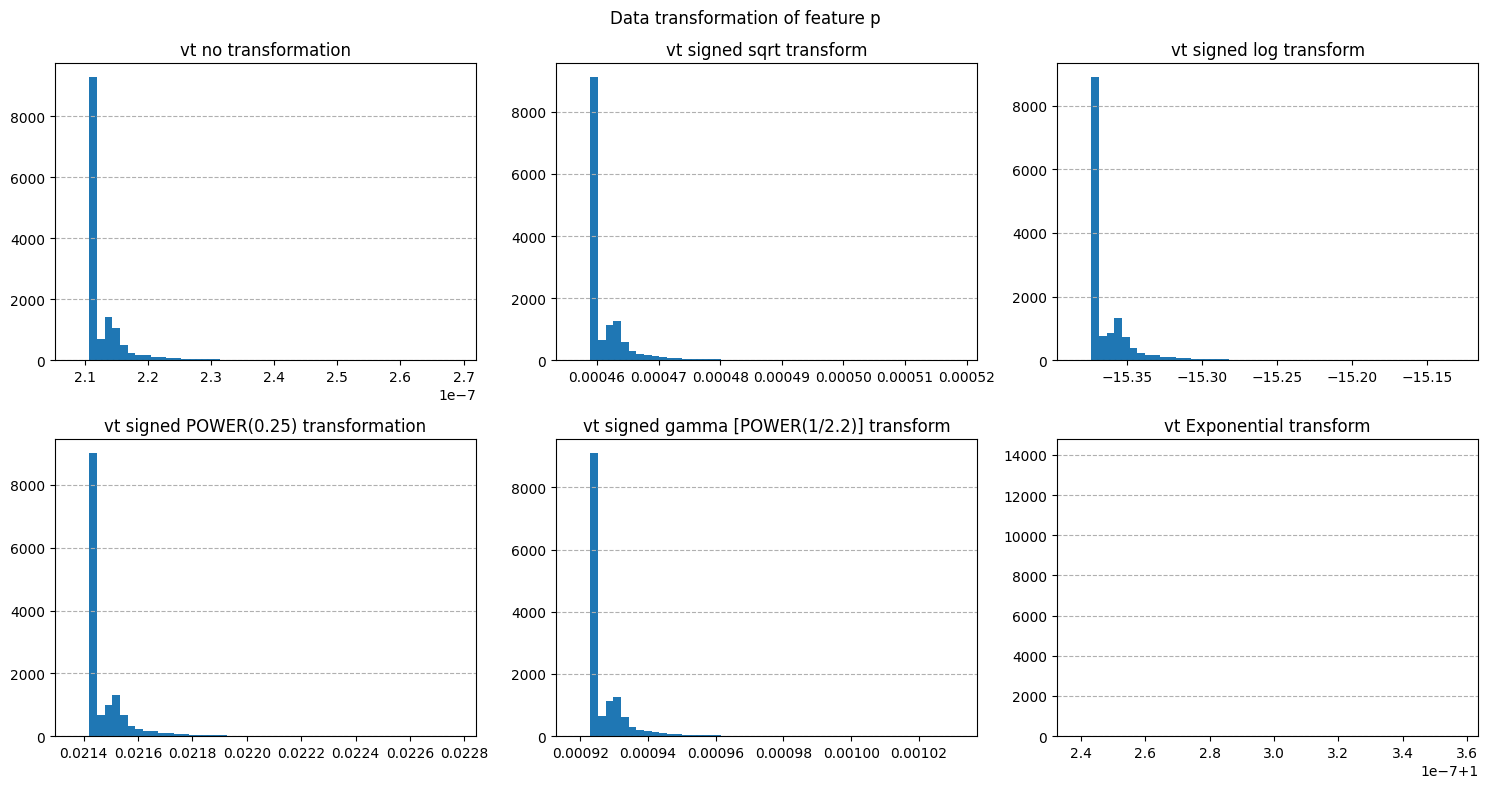

In [92]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

ax[0,0].hist(b['y'][feat].reshape(-1), bins=50)
ax[0,0].set_title('vt no transformation')
ax[0,0].grid(axis='y', linestyle='--', which='major')

ax[0,1].hist(sqrt_transform(b['y'][feat]).reshape(-1), bins=50)
ax[0,1].set_title('vt signed sqrt transform')
ax[0,1].grid(axis='y', linestyle='--', which='major')

ax[0,2].hist(log_transform(b['y'][feat]).reshape(-1), bins=50)
ax[0,2].set_title('vt signed log transform')
ax[0,2].grid(axis='y', linestyle='--', which='major')

ax[1,0].hist(power_transform(b['y'][feat], 0.25).reshape(-1), bins=50)
ax[1,0].set_title('vt signed POWER(0.25) transformation')
ax[1,0].grid(axis='y', linestyle='--', which='major')

ax[1,1].hist(power_transform(b['y'][feat], 1/2.2).reshape(-1), bins=50)
ax[1,1].set_title('vt signed gamma [POWER(1/2.2)] transform')
ax[1,1].grid(axis='y', linestyle='--', which='major')

ax[1,2].hist(exp_transform(b['y'][feat]).reshape(-1), bins=50)
ax[1,2].set_title('vt Exponential transform')
ax[1,2].grid(axis='y', linestyle='--', which='major')

plt.suptitle(f'Data transformation of feature {LABELS[feat]}')
plt.savefig(f'{save_filepath}/possible_transforms/{LABELS[feat]}.pdf', dpi=200)
plt.tight_layout()
plt.show()

In [127]:
def get_sim(sim_path, scale_up):
    # (v_path,) = [path_join(sim_path, file_name) for file_name in FILE_NAMES]
    v_list = [read_hdf(path_join(sim_path, file_name), ['Data-Set-2'])[0] for file_name in FILE_NAMES]
    print(v_list[0].shape)
    v_0 = np.array([t for t in v[0]])
    v_0 = v_0.transpose(2,1,0)

    if scale_up != 1:
        v_0 = enlarge_cube(v_0, scale_up)
    return v_0

In [129]:
v = get_sim(sim_path, 1)
# file_name = FILE_NAMES[0]
# v = read_hdf(path_join(sim_path, file_name), ['Data-Set-2'])

(361, 157, 499)


In [131]:
v.shape

(499, 157, 361)

In [133]:
def enlarge_cube(cube, scale1, scale2):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale1, scale2), order=1)

In [134]:
v_zoom = enlarge_cube(v, 110/157, 128/361)

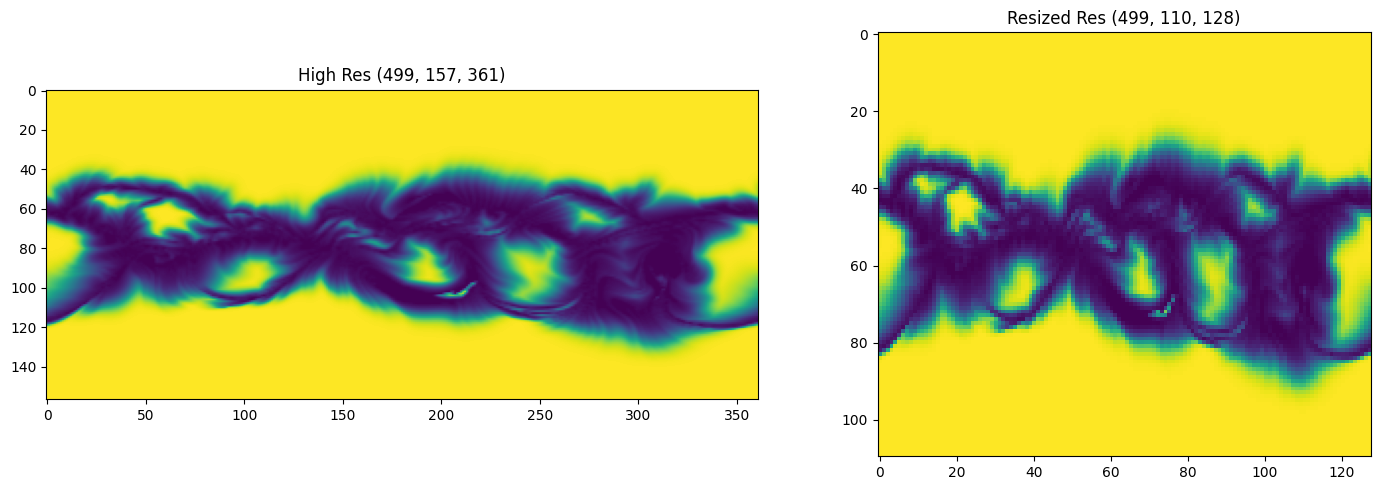

In [142]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].imshow(v[0])
ax[0].set_title(f'High Res {v.shape}')
ax[1].imshow(v_zoom[0])
ax[1].set_title(f'Resized Res {v_zoom.shape}')
plt.tight_layout()
plt.show()

In [115]:
def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    radii, thetas, phis = read_hdf(v_path, ["fakeDim2","fakeDim1", "fakeDim0"])
    return radii, thetas, phis

In [116]:
r,t,p = get_coords(sim_path)

In [117]:
r.shape

(499,)

In [118]:
r

array([ 30.      ,  30.414577,  30.829157,  31.243734,  31.658314,
        32.07289 ,  32.48747 ,  32.90205 ,  33.316628,  33.731205,
        34.145782,  34.56036 ,  34.97494 ,  35.38952 ,  35.804096,
        36.218674,  36.63325 ,  37.047832,  37.46241 ,  37.876987,
        38.291565,  38.706146,  39.120724,  39.5353  ,  39.94988 ,
        40.364456,  40.779037,  41.193615,  41.608192,  42.02277 ,
        42.43735 ,  42.85193 ,  43.266506,  43.681084,  44.09566 ,
        44.510242,  44.92482 ,  45.339397,  45.753975,  46.168552,
        46.583134,  46.99771 ,  47.41229 ,  47.826866,  48.241447,
        48.656025,  49.070602,  49.48518 ,  49.899757,  50.31434 ,
        50.728916,  51.143494,  51.55807 ,  51.972652,  52.38723 ,
        52.801807,  53.216385,  53.630962,  54.045544,  54.46012 ,
        54.8747  ,  55.289276,  55.703854,  56.118435,  56.533012,
        56.94759 ,  57.362167,  57.77675 ,  58.191326,  58.605904,
        59.02048 ,  59.43506 ,  59.84964 ,  60.264217,  60.678